# EDA
We are gonna explore churn datas.

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('../data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# clean dataframe
import sys
sys.path.append("..")
from cleaning import clean

df = clean(df)

In [ ]:
import matplotlib.pyplot as plt

# 1. Churn Overview


In [ ]:
df["Churn"].value_counts(normalize=True)*100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

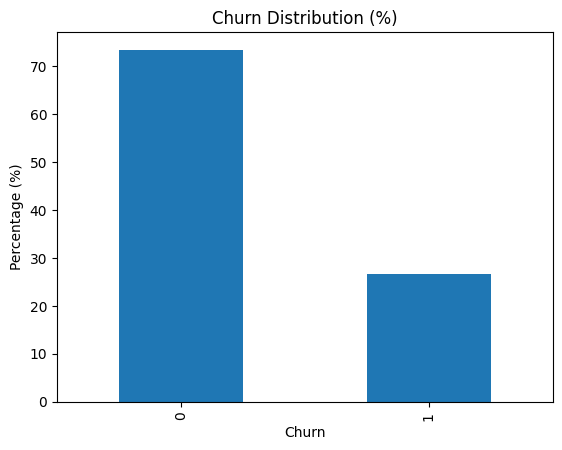

In [ ]:
churn_percent = df["Churn"].value_counts(normalize=True) * 100

churn_percent.plot(kind="bar")

plt.title("Churn Distribution (%)")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")

plt.show()


This means the company has a cancellation rate of approximately 27%, a worrying figure.

# 2. Univariate analysis

## Churn per Contract type


In [ ]:
df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)*100

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

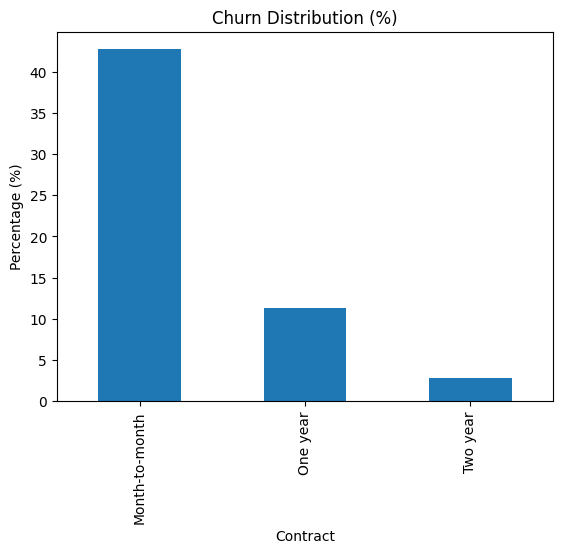

In [ ]:
churn_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100

churn_contract.plot(kind="bar")

plt.title("Churn Distribution (%)")
plt.xlabel("Contract")
plt.ylabel("Percentage (%)")

plt.show()

### Insight 
Customers with monthly contracts have:

-4x more churn than annual contracts

-15x more churn than 2-year contracts


This strongly suggests that:

-long-term contracts generate retention

-monthly customers have low commitment

-probably more sensitive to price and competition

## Churn per Payment Method



In [ ]:
df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)*100

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

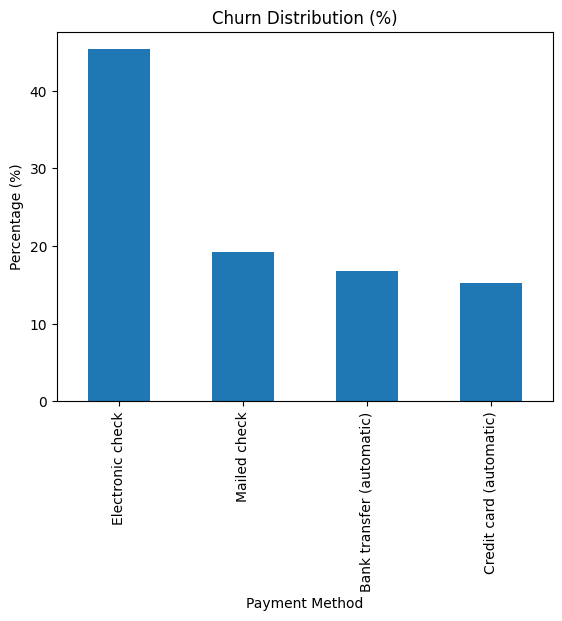

In [ ]:
churn_payment = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False) * 100

churn_payment.plot(kind="bar")

plt.title("Churn Distribution (%)")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")

plt.show()

### Insight
Non-automated payment methods have much higher churn rates.

Key point:

-Electronic check = almost 3x more churn than automated methods.

-Automatic payment significantly reduces cancellations.

This suggests:

-Customers with manual payment have less "connection" with the service.

-Less automation → greater chance of forgetting or canceling.

-Possible friction or poor payment experience.

## Internet Service


In [ ]:
df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)*100

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

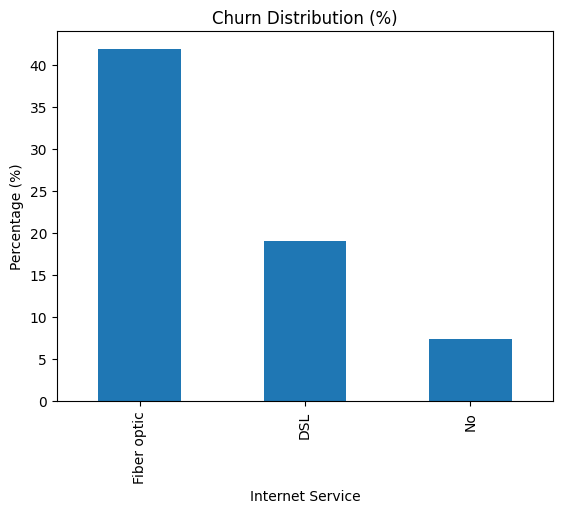

In [ ]:
churn_internet = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False) * 100

churn_internet.plot(kind="bar")

plt.title("Churn Distribution (%)")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")

plt.show()

### Insight
Customers using Fiber Optic tend to show higher churn rates compared to DSL and customers without internet service, suggesting that service type may influence customer retention.


## SeniorCitizen



In [ ]:
df.groupby('SeniorCitizen')["Churn"].mean().sort_values(ascending=False)*100

SeniorCitizen
1    41.681261
0    23.650255
Name: Churn, dtype: float64

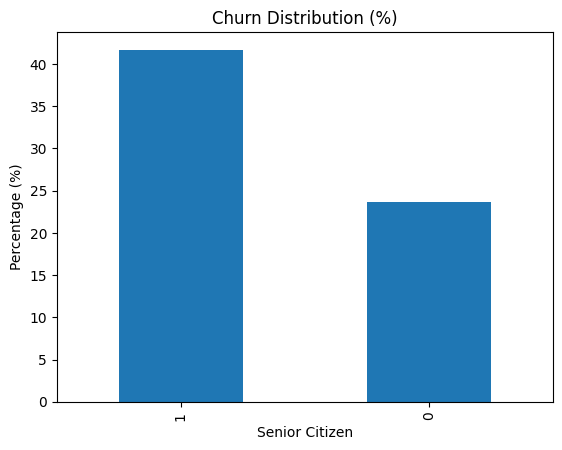

In [ ]:
churn_senior = df.groupby("SeniorCitizen")["Churn"].mean().sort_values(ascending=False) * 100

churn_senior.plot(kind="bar")

plt.title("Churn Distribution (%)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")

plt.show()

### Insight
Senior citizens present significantly higher churn rates compared to non-senior customers, indicating that age-related factors may influence customer retention.

# 3. Multivariate Analysis

## Customer profile with the highest risk of churn

In [ ]:
df.groupby(["Contract", "PaymentMethod"])["Churn"].mean().sort_values(ascending=False)*100

Contract        PaymentMethod            
Month-to-month  Electronic check             53.729730
                Bank transfer (automatic)    34.125637
                Credit card (automatic)      32.780847
                Mailed check                 31.578947
One year        Electronic check             18.443804
                Credit card (automatic)      10.301508
                Bank transfer (automatic)     9.718670
Two year        Electronic check              7.738095
One year        Mailed check                  6.845238
Two year        Bank transfer (automatic)     3.380783
                Credit card (automatic)       2.241379
                Mailed check                  0.800000
Name: Churn, dtype: float64

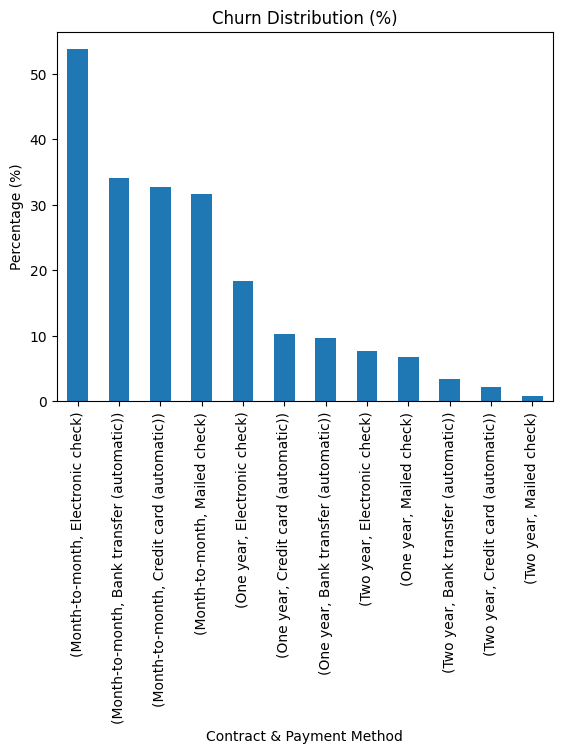

In [ ]:
churn_contract_payment = df.groupby(["Contract", "PaymentMethod"])["Churn"].mean().sort_values(ascending=False)*100

churn_contract_payment.plot(kind="bar")

plt.title("Churn Distribution (%)")
plt.xlabel("Contract & Payment Method")
plt.ylabel("Percentage (%)")

plt.show()

### Insight
This result clearly shows that churn doesn't depend on just one variable, but on a combination:

High-risk customer:

-monthly contract

-manual payment (electronic check)

These customers are:

-less loyal

-easier to cancel

-probably more sensitive to price and competition

On the other hand we have low-risk client:

-2-year contract

-Automatic payment (card/bank transfer)

Churn rate close to 0% to 3%.

# 4. Key Insights

After performing exploratory data analysis on customer churn data, several important patterns were identified:

- Customers with **month-to-month contracts** show the highest churn rate (~42%), while long-term contracts (one and two years) significantly reduce churn, especially two-year contracts (~3%).

- Payment method is a strong indicator of churn behavior. Customers using **electronic check** have a much higher churn rate (~45%) compared to automatic payment methods such as credit card or bank transfer (~15–17%).

- Customers using **fiber optic internet service** tend to have higher churn rates compared to DSL and customers without internet service.

- **Senior citizens** show a significantly higher churn rate (~41%) compared to non-senior customers (~23%), indicating potential age-related retention challenges.

- The combination of **month-to-month contracts and electronic check payment method** represents the highest-risk customer segment, with churn rates exceeding 50%.

Overall, the analysis suggests that customer retention is strongly influenced by contract type, payment method, and service configuration. Increasing contract duration and promoting automatic payment methods could significantly reduce churn.